# DataTour — Starter Notebook ultra-minimal

Ce notebook fournit une baseline très simple : chargement des données, quelques features, entraînement sur tout le train, puis génération de `submission.csv`.

Il ne contient pas de validation temporelle, pas de comparaison de modèles, pas de graphiques et pas d’analyse avancée.


In [ ]:
# DataTour — Starter Notebook ultra-minimal
# Détection de fraude Mobile Money
#
# Objectif:
# - charger les données
# - créer quelques variables simples
# - entraîner un modèle baseline sur tout le train
# - générer submission.csv

import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


DATA_DIR = Path(".")  # dossier contenant train.csv, test.csv, sample_submission.csv

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

ID_COL = "id"
TARGET_COL = "fraud_flag"

print("train:", train.shape)
print("test :", test.shape)
display(train.head())


# Contrôles rapides

print("Taux de fraude:", train[TARGET_COL].mean())
print("Valeurs manquantes train:", train.isna().sum().sum())
print("Valeurs manquantes test :", test.isna().sum().sum())



train: (1290081, 11)
test : (430100, 10)


,id,period,operation,amount,origin_account,origin_balance_before,origin_balance_after,destination_account,destination_balance_before,destination_balance_after,fraud_flag
0,dtf_0000001_ffa5beb5,0,op_05,636.75,acc_o_307358626ad66fed,87.00,-549.75,acc_d_7fac3b16af7d127b,630.88,1267.62,0
1,dtf_0000002_61992e82,0,op_05,636.12,acc_o_aeb690c57bf5d1de,76.93,76.93,acc_d_1d6120e8b117aa14,731.70,731.70,0
2,dtf_0000003_9a123b6d,0,op_05,681.00,acc_o_655c41913944d2b7,15943.74,15262.75,acc_d_ec2c21517a0ccb1a,758.83,1439.84,0
3,dtf_0000004_240f3dae,0,op_03,28175.40,acc_o_ba23a2b955a79a8b,-443.88,-28619.28,acc_d_a3dd8504815ec133,770924.84,799100.24,0
4,dtf_0000005_f18939e7,0,op_03,86429.15,acc_o_d05a23079bd066c1,-670.85,-87100.01,acc_d_0d4880267e62d5c4,91.13,86520.29,0


Taux de fraude: 0.10041384998306307
Valeurs manquantes train: 0
Valeurs manquantes test : 0


In [ ]:
train[::-1].head()

,id,period,operation,amount,origin_account,origin_balance_before,origin_balance_after,destination_account,destination_balance_before,destination_balance_after,fraud_flag
1290080,dtf_1290081_32be8ff7,105,op_03,89406.15,acc_o_a2df884812f3de57,623091.64,533685.47,acc_d_33e26a1331ec21eb,0.00,89406.15,1
1290079,dtf_1290080_d96382d2,105,op_05,711.40,acc_o_afaa6e5b6f55080f,2950643.39,2949931.99,acc_d_4b17724e353c1753,142609.30,143320.70,0
1290078,dtf_1290079_50f34347,105,op_05,633.99,acc_o_616eef85e0db107c,3527609.44,3526975.45,acc_d_3a161415514ba10f,276896.11,277530.10,0
1290077,dtf_1290078_07a32f90,105,op_03,19849.22,acc_o_4b132d78462d49d3,2593327.03,2573477.82,acc_d_d108b3d1928206ab,163529.43,183378.64,1
1290076,dtf_1290077_4b26aa01,105,op_05,667.47,acc_o_76b7f5595d9f2c9f,1688715.14,1688047.68,acc_d_661177be3e5965ca,203607.32,204274.77,0


In [ ]:
train.info()
train.describe()
train.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1290081 entries, 0 to 1290080
Data columns (total 11 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   id                          1290081 non-null  object 
 1   period                      1290081 non-null  int64  
 2   operation                   1290081 non-null  object 
 3   amount                      1290081 non-null  float64
 4   origin_account              1290081 non-null  object 
 5   origin_balance_before       1290081 non-null  float64
 6   origin_balance_after        1290081 non-null  float64
 7   destination_account         1290081 non-null  object 
 8   destination_balance_before  1290081 non-null  float64
 9   destination_balance_after   1290081 non-null  float64
 10  fraud_flag                  1290081 non-null  int64  
dtypes: float64(5), int64(2), object(4)
memory usage: 108.3+ MB


,0
id,1290081
period,106
operation,5
amount,464079
origin_account,13431
origin_balance_before,1245326
origin_balance_after,1247168
destination_account,15818
destination_balance_before,591925
destination_balance_after,651769


In [ ]:
train['operation'].unique()

array(['op_05', 'op_03', 'op_04', 'op_02', 'op_01'], dtype=object)

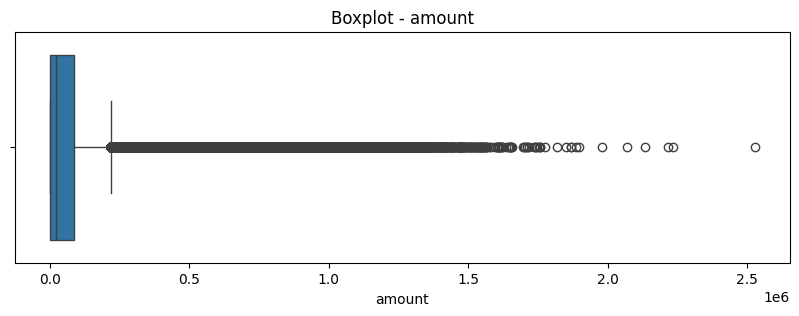

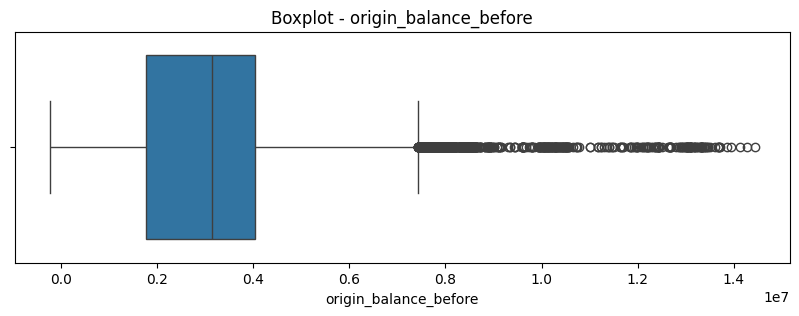

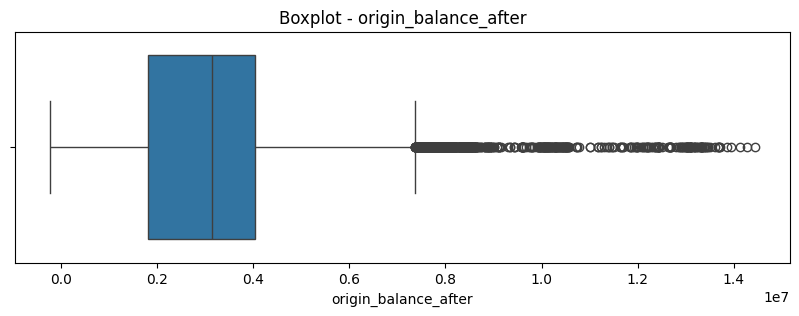

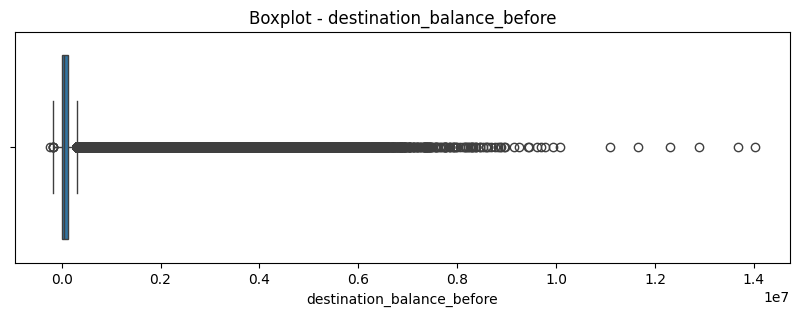

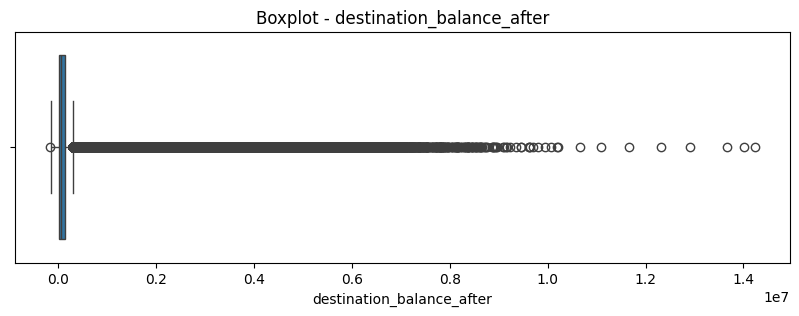

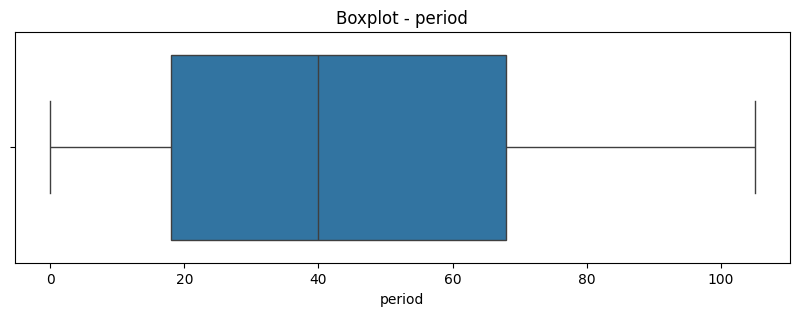

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = [
    "amount",
    "origin_balance_before",
    "origin_balance_after",
    "destination_balance_before",
    "destination_balance_after",
    "period"
]

for col in num_cols:
    plt.figure(figsize=(10,3))
    sns.boxplot(x=train[col])
    plt.title(f"Boxplot - {col}")
    plt.show()

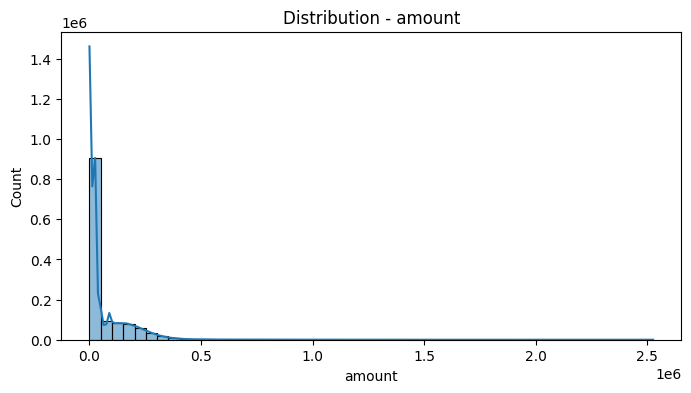

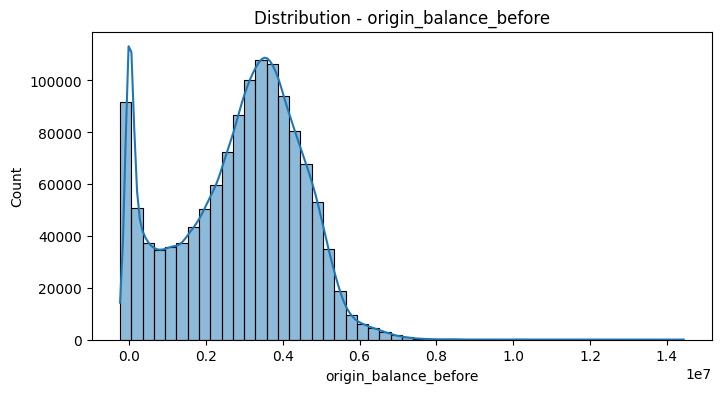

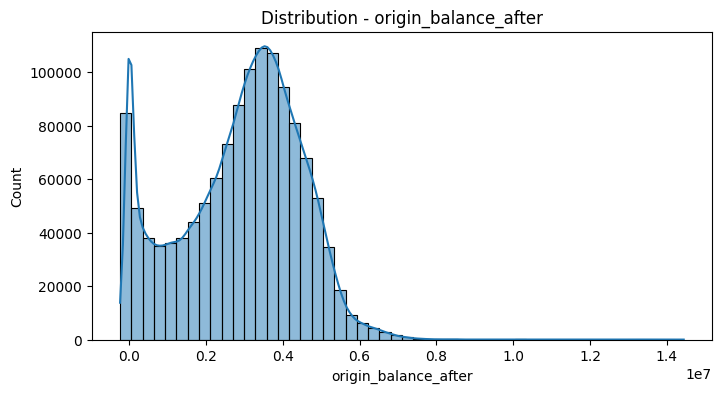

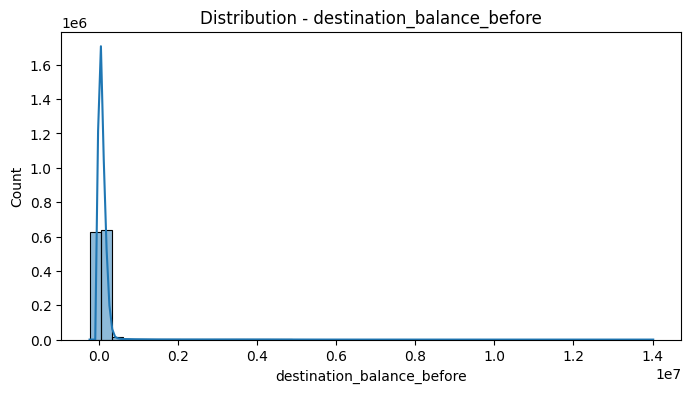

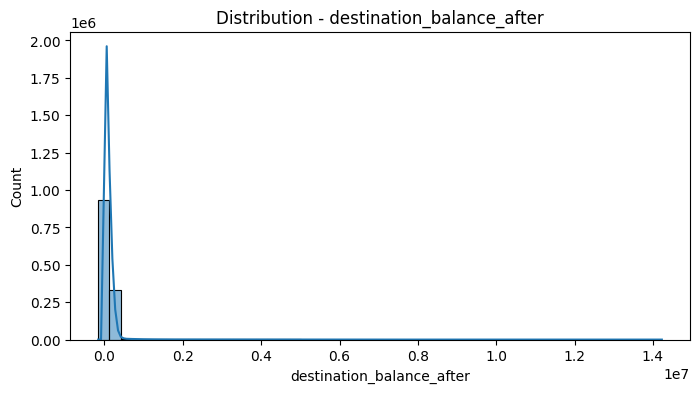

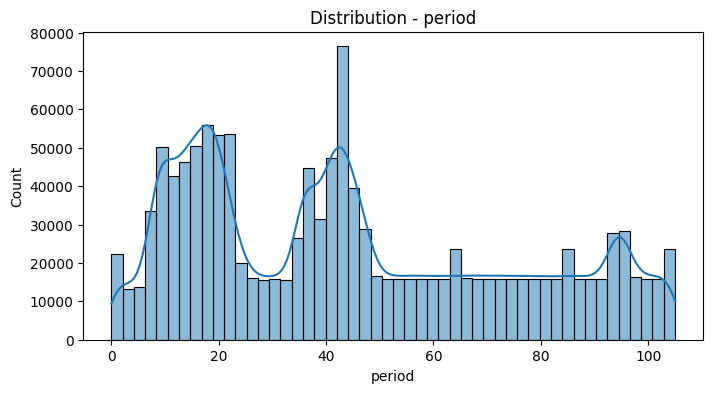

In [ ]:
for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(train[col], bins=50, kde=True)
    plt.title(f"Distribution - {col}")
    plt.show()

In [ ]:
cols = [
    "origin_balance_before",
    "origin_balance_after",
    "destination_balance_before",
    "destination_balance_after"
]

for col in cols:
    print(col, (train[col] < 0).sum())

origin_balance_before 32122
origin_balance_after 32486
destination_balance_before 99
destination_balance_after 15


In [ ]:
print(
    train["fraud_flag"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

fraud_flag
0    89.96
1    10.04
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# ÉTAPE 1 — DATA CLEANING
# ============================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# ============================================================
# 1.1 — CHARGEMENT DES DONNÉES
# ============================================================

train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")

print("Shape train :", train.shape)
print("Shape test  :", test.shape)
print()

# Séparation features / cible
TARGET = "fraud_flag"
ID_COL = "id"

y_train = train[TARGET].copy()
X_train = train.drop(columns=[TARGET, ID_COL])
X_test  = test.drop(columns=[ID_COL])

print("Distribution de la cible :")
print(y_train.value_counts(normalize=True).mul(100).round(2))
print()

# ============================================================
# 1.2 — VÉRIFICATIONS RAPIDES (déjà validées, juste pour log)
# ============================================================

print("=== Vérifications ===")
print(f"NaN train     : {X_train.isna().sum().sum()}")
print(f"Doublons train: {train.duplicated().sum()}")
print(f"NaN test      : {X_test.isna().sum().sum()}")
print(f"Doublons test : {test.duplicated().sum()}")
print()

# ============================================================
# 1.3 — TRAITEMENT DES VALEURS NÉGATIVES
# Colonnes concernées : soldes origin (32 000+ cas)
#                       soldes destination (< 120 cas)
# Stratégie : créer un flag binaire AVANT de clipper
# ============================================================

balance_cols = [
    "origin_balance_before",
    "origin_balance_after",
    "destination_balance_before",
    "destination_balance_after"
]

print("=== Valeurs négatives (avant traitement) ===")
for col in balance_cols:
    n_neg_train = (X_train[col] < 0).sum()
    n_neg_test  = (X_test[col] < 0).sum()
    print(f"  {col:35s} | train: {n_neg_train:>6} | test: {n_neg_test:>6}")
print()

# --- Créer les flags binaires (avant clipping) ---
for col in balance_cols:
    flag_name = f"{col}_is_negative"
    X_train[flag_name] = (X_train[col] < 0).astype(int)
    X_test[flag_name]  = (X_test[col]  < 0).astype(int)

# --- Clipper les négatifs à 0 ---
for col in balance_cols:
    X_train[col] = X_train[col].clip(lower=0)
    X_test[col]  = X_test[col].clip(lower=0)

print("=== Valeurs négatives (après clipping) ===")
for col in balance_cols:
    print(f"  {col:35s} | train: {(X_train[col] < 0).sum()} | test: {(X_test[col] < 0).sum()}")
print()

# ============================================================
# 1.4 — ENCODAGE DE LA VARIABLE CATÉGORIELLE
# ============================================================

# Identifier les colonnes catégorielles
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"Colonnes catégorielles détectées : {cat_cols}")

if cat_cols:
    for col in cat_cols:
        n_unique = X_train[col].nunique()
        print(f"  {col} → {n_unique} modalités uniques")
        print(f"  Valeurs : {X_train[col].unique()[:10]}")
        print()

        if n_unique <= 10:
            # Peu de modalités → Label Encoding simple
            le = LabelEncoder()
            # Fit sur train + test combinés pour éviter les modalités inconnues
            combined = pd.concat([X_train[col], X_test[col]], axis=0).astype(str)
            le.fit(combined)
            X_train[col] = le.transform(X_train[col].astype(str))
            X_test[col]  = le.transform(X_test[col].astype(str))
            print(f"  → Label Encoding appliqué sur '{col}'")

        else:
            # Beaucoup de modalités → Target Encoding
            # (sera fait dans l'étape 2 avec cross-val pour éviter le data leakage)
            print(f"  → '{col}' a {n_unique} modalités, Target Encoding recommandé (étape 2)")
else:
    print("  Aucune colonne catégorielle détectée.")
print()

# ============================================================
# 1.5 — VÉRIFICATION FINALE
# ============================================================

print("=== État final du dataset ===")
print(f"X_train shape : {X_train.shape}")
print(f"X_test  shape : {X_test.shape}")
print()
print("Colonnes finales :")
print(X_train.dtypes)
print()
print(f"NaN restants train : {X_train.isna().sum().sum()}")
print(f"NaN restants test  : {X_test.isna().sum().sum()}")

Shape train : (1290081, 11)
Shape test  : (430100, 10)

Distribution de la cible :
fraud_flag
0    89.96
1    10.04
Name: proportion, dtype: float64

=== Vérifications ===
NaN train     : 0
Doublons train: 0
NaN test      : 0
Doublons test : 0

=== Valeurs négatives (avant traitement) ===
  origin_balance_before               | train:  32122 | test:  12280
  origin_balance_after                | train:  32486 | test:  12135
  destination_balance_before          | train:     99 | test:     18
  destination_balance_after           | train:     15 | test:      0

=== Valeurs négatives (après clipping) ===
  origin_balance_before               | train: 0 | test: 0
  origin_balance_after                | train: 0 | test: 0
  destination_balance_before          | train: 0 | test: 0
  destination_balance_after           | train: 0 | test: 0

Colonnes catégorielles détectées : ['operation', 'origin_account', 'destination_account']
  operation → 5 modalités uniques
  Valeurs : ['op_05' 'op_03' 

In [ ]:

# Recombiner avec les IDs pour sauvegarde propre
train_clean = X_train.copy()
train_clean[TARGET] = y_train
train_clean[ID_COL] = train[ID_COL]

test_clean = X_test.copy()
test_clean[ID_COL] = test[ID_COL]

train_clean.to_csv("train_clean.csv", index=False)
test_clean.to_csv("test_clean.csv",  index=False)

print()
print("✅ Étape 1 terminée.")
print("   → train_clean.csv sauvegardé")
print("   → test_clean.csv  sauvegardé")
print()
print("Nouvelles colonnes ajoutées :")
new_cols = [c for c in X_train.columns if c not in train.columns]
for c in new_cols:
    print(f"   + {c}")


✅ Étape 1 terminée.
   → train_clean.csv sauvegardé
   → test_clean.csv  sauvegardé

Nouvelles colonnes ajoutées :
   + origin_balance_before_is_negative
   + origin_balance_after_is_negative
   + destination_balance_before_is_negative
   + destination_balance_after_is_negative


In [ ]:
# ============================================================
# ÉTAPE 2 — FEATURE ENGINEERING (VERSION CORRIGÉE, SANS LEAKAGE)
# Compétition : Détection de Fraude Mobile Money
# ============================================================

import pandas as pd
import numpy as np


def feature_engineering(X_train, X_test, y_train):
    """
    Feature engineering SANS leakage.

    Supprimé par rapport à v1 :
      ❌ origin_fraud_rate      (basé sur fraud_flag → leakage)
      ❌ dest_fraud_rate        (basé sur fraud_flag → leakage)
      ❌ period_fraud_rate      (basé sur fraud_flag → leakage)
      ❌ origin_account_target_enc  (idem)
      ❌ destination_account_target_enc (idem)

    Conservé :
      ✅ Toutes les agrégations neutres (count, mean, max, std)
      ✅ Toutes les features de delta et binaires
      ✅ Toutes les transformations log1p
    """

    n_train = len(X_train)
    df = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)

    print("=== FEATURE ENGINEERING (sans leakage) ===")
    print(f"  Taille combinée : {df.shape}")
    print()

    # --------------------------------------------------------
    # 2.1 — FEATURES DE DELTA
    # --------------------------------------------------------
    print("--- 2.1 Features de delta ---")

    df["delta_origin"]     = df["origin_balance_before"] - df["origin_balance_after"]
    df["delta_dest"]       = df["destination_balance_after"] - df["destination_balance_before"]
    df["ratio_ponction"]   = df["amount"] / (df["origin_balance_before"] + 1)
    df["amount_vs_dest"]   = df["amount"] / (df["destination_balance_before"] + 1)
    df["coherence_origin"] = np.abs(df["delta_origin"] - df["amount"])
    df["coherence_dest"]   = np.abs(df["delta_dest"]   - df["amount"])

    print("  ✅ delta_origin, delta_dest")
    print("  ✅ ratio_ponction, amount_vs_dest")
    print("  ✅ coherence_origin, coherence_dest")
    print()

    # --------------------------------------------------------
    # 2.2 — FEATURES BINAIRES
    # --------------------------------------------------------
    print("--- 2.2 Features binaires ---")

    df["dest_was_empty"]         = (df["destination_balance_before"] == 0).astype(int)
    df["dest_emptied"]           = ((df["destination_balance_after"] == 0) & (df["amount"] > 0)).astype(int)
    df["origin_empty"]           = (df["origin_balance_before"] == 0).astype(int)
    df["origin_vidé"]            = (df["origin_balance_after"]  == 0).astype(int)
    df["money_mule_pattern"]     = ((df["dest_was_empty"] == 1) & (df["dest_emptied"] == 1)).astype(int)
    df["origin_empty_but_sends"] = ((df["origin_empty"] == 1) & (df["amount"] > 0)).astype(int)
    df["dest_transit"]           = ((df["amount"] > 0) & (np.abs(df["delta_dest"]) < 1)).astype(int)

    print("  ✅ dest_was_empty, dest_emptied, origin_empty, origin_vidé")
    print("  ✅ money_mule_pattern, origin_empty_but_sends, dest_transit")
    print()

    # --------------------------------------------------------
    # 2.3 — TRANSFORMATIONS LOG1P
    # --------------------------------------------------------
    print("--- 2.3 Transformations log1p ---")

    log_cols = [
        "amount",
        "origin_balance_before",
        "origin_balance_after",
        "destination_balance_before",
        "destination_balance_after",
        "delta_origin",
        "delta_dest",
        "coherence_origin",
        "coherence_dest",
    ]

    for col in log_cols:
        df[f"log_{col}"] = np.log1p(df[col].clip(lower=0))

    print(f"  ✅ log1p appliqué sur {len(log_cols)} colonnes")
    print()

    # --------------------------------------------------------
    # 2.4 — AGRÉGATIONS PAR PERIOD (sans fraud_flag)
    # --------------------------------------------------------
    print("--- 2.4 Agrégations par period ---")

    # Calculées sur train+test → pas de leakage (pas de cible utilisée)
    period_agg = df.groupby("period").agg(
        period_nb_transactions = ("amount", "count"),
        period_amount_mean     = ("amount", "mean"),
        period_amount_sum      = ("amount", "sum"),
        period_amount_std      = ("amount", "std"),
    ).reset_index()

    df = df.merge(period_agg, on="period", how="left")

    print("  ✅ period_nb_transactions, period_amount_mean")
    print("  ✅ period_amount_sum, period_amount_std")
    print("  ❌ period_fraud_rate supprimé (leakage)")
    print()

    # --------------------------------------------------------
    # 2.5 — AGRÉGATIONS PAR origin_account (sans fraud_flag)
    # --------------------------------------------------------
    print("--- 2.5 Agrégations par origin_account ---")

    # Calculées sur train+test → safe
    origin_agg = df.groupby("origin_account").agg(
        origin_nb_transactions = ("amount", "count"),
        origin_amount_mean     = ("amount", "mean"),
        origin_amount_max      = ("amount", "max"),
        origin_amount_std      = ("amount", "std"),
        origin_nb_dest_uniques = ("destination_account", "nunique"),
    ).reset_index()

    df = df.merge(origin_agg, on="origin_account", how="left")

    print("  ✅ origin_nb_transactions, origin_amount_mean/max/std")
    print("  ✅ origin_nb_dest_uniques")
    print("  ❌ origin_fraud_rate supprimé (leakage)")
    print()

    # --------------------------------------------------------
    # 2.6 — AGRÉGATIONS PAR destination_account (sans fraud_flag)
    # --------------------------------------------------------
    print("--- 2.6 Agrégations par destination_account ---")

    dest_agg = df.groupby("destination_account").agg(
        dest_nb_transactions   = ("amount", "count"),
        dest_amount_mean       = ("amount", "mean"),
        dest_amount_max        = ("amount", "max"),
        dest_amount_std        = ("amount", "std"),
        dest_nb_origin_uniques = ("origin_account", "nunique"),
    ).reset_index()

    df = df.merge(dest_agg, on="destination_account", how="left")

    print("  ✅ dest_nb_transactions, dest_amount_mean/max/std")
    print("  ✅ dest_nb_origin_uniques")
    print("  ❌ dest_fraud_rate supprimé (leakage)")
    print()

    # --------------------------------------------------------
    # 2.7 — SUPPRESSION DES COLONNES INUTILES
    #        (comptes anonymisés → trop de cardinalité, déjà agrégés)
    # --------------------------------------------------------
    print("--- 2.7 Suppression des colonnes inutiles ---")

    drop_cols = ["origin_account", "destination_account"]
    df = df.drop(columns=drop_cols)

    print(f"  ✅ Supprimé : {drop_cols}")
    print()

    # --------------------------------------------------------
    # SÉPARATION TRAIN / TEST
    # --------------------------------------------------------
    X_train_fe = df.iloc[:n_train].reset_index(drop=True)
    X_test_fe  = df.iloc[n_train:].reset_index(drop=True)

    print("=== RÉSUMÉ FINAL ===")
    print(f"  X_train_fe shape : {X_train_fe.shape}")
    print(f"  X_test_fe  shape : {X_test_fe.shape}")
    print()
    print(f"  NaN train : {X_train_fe.isna().sum().sum()}")
    print(f"  NaN test  : {X_test_fe.isna().sum().sum()}")

    X_train_fe = X_train_fe.fillna(0)
    X_test_fe  = X_test_fe.fillna(0)

    print("  ✅ NaN résiduels remplis à 0")
    print()

    print("Colonnes finales :")
    for c in X_train_fe.columns:
        print(f"  - {c}")

    print()
    print("✅ Feature Engineering (sans leakage) terminé.")

    return X_train_fe, X_test_fe

In [ ]:
X_train_fe, X_test_fe = feature_engineering(X_train, X_test, y_train)

# Sauvegarde
X_train_fe.to_csv("train_fe.csv", index=False)
X_test_fe.to_csv("test_fe.csv",   index=False)
y_train.to_csv("y_train.csv",     index=False)

print("→ train_fe.csv, test_fe.csv, y_train.csv sauvegardés")
print()
print("Aperçu des colonnes finales :")
print(X_train_fe.dtypes)

=== FEATURE ENGINEERING (sans leakage) ===
  Taille combinée : (1720181, 13)

--- 2.1 Features de delta ---
  ✅ delta_origin, delta_dest
  ✅ ratio_ponction, amount_vs_dest
  ✅ coherence_origin, coherence_dest

--- 2.2 Features binaires ---
  ✅ dest_was_empty, dest_emptied, origin_empty, origin_vidé
  ✅ money_mule_pattern, origin_empty_but_sends, dest_transit

--- 2.3 Transformations log1p ---
  ✅ log1p appliqué sur 9 colonnes

--- 2.4 Agrégations par period ---
  ✅ period_nb_transactions, period_amount_mean
  ✅ period_amount_sum, period_amount_std
  ❌ period_fraud_rate supprimé (leakage)

--- 2.5 Agrégations par origin_account ---
  ✅ origin_nb_transactions, origin_amount_mean/max/std
  ✅ origin_nb_dest_uniques
  ❌ origin_fraud_rate supprimé (leakage)

--- 2.6 Agrégations par destination_account ---
  ✅ dest_nb_transactions, dest_amount_mean/max/std
  ✅ dest_nb_origin_uniques
  ❌ dest_fraud_rate supprimé (leakage)

--- 2.7 Suppression des colonnes inutiles ---
  ✅ Supprimé : ['origin_a

In [ ]:

# # Préparation train/test

# train_fe, freq_maps = add_features(train, fit=True)
# test_fe, _ = add_features(test, freq_maps=freq_maps)

# X_train = train_fe.drop(columns=[ID_COL, TARGET_COL])
# y_train = train_fe[TARGET_COL]
# X_test = test_fe.drop(columns=[ID_COL])

# categorical_cols = X_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()
# numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

# try:
#     onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
# except TypeError:
#     onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

# preprocess = ColumnTransformer(
#     transformers=[
#         ("num", SimpleImputer(strategy="median"), numeric_cols),
#         ("cat", onehot, categorical_cols),
#     ],
#     sparse_threshold=0.0,
# )

# model = HistGradientBoostingClassifier(
#     max_iter=150,
#     learning_rate=0.06,
#     max_leaf_nodes=31,
#     random_state=42,
# )

# pipe = Pipeline([
#     ("preprocess", preprocess),
#     ("model", model),
# ])


# # Entraînement sur tout le train

# pipe.fit(X_train, y_train)

In [ ]:
# ID_COL     = "id"
# TARGET_COL = "fraud_flag"

# train_fe, agg_maps, freq_maps = features_engineering(train, fit=True)
# test_fe, _, _                 = features_engineering(test, agg_maps=agg_maps, freq_maps=freq_maps)

# X_train = train_fe.drop(columns=[ID_COL, TARGET_COL])
# y_train = train_fe[TARGET_COL]
# X_test  = test_fe.drop(columns=[ID_COL])

# print("Features:", X_train.shape[1])
# print(X_train.dtypes.value_counts())

In [ ]:
# from sklearn.preprocessing import LabelEncoder

# le = LabelEncoder()
# X_train["operation"] = le.fit_transform(X_train["operation"])
# X_test["operation"]  = le.transform(X_test["operation"])

In [ ]:
# import lightgbm as lgb
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import average_precision_score

# X_tr, X_val, y_tr, y_val = train_test_split(
#     X_train, y_train,
#     test_size=0.1,
#     stratify=y_train,
#     random_state=42
# )

# scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()
# print(f"scale_pos_weight : {scale_pos_weight:.2f}")

# model = lgb.LGBMClassifier(
#     objective="binary",
#     metric="average_precision",
#     n_estimators=3000,
#     learning_rate=0.02,        # plus lent = meilleur généralement
#     num_leaves=63,             # réduit pour éviter l'overfit rapide
#     min_child_samples=100,     # au moins 100 samples par feuille
#     scale_pos_weight=scale_pos_weight,
#     subsample=0.8,
#     subsample_freq=1,
#     colsample_bytree=0.8,
#     reg_alpha=0.1,             # régularisation L1
#     reg_lambda=1.0,            # régularisation L2
#     cat_smooth=10,
#     random_state=42,
#     n_jobs=-1,
#     verbose=-1,
# )

# model.fit(
#     X_tr, y_tr,
#     eval_set=[(X_val, y_val)],
#     callbacks=[
#         lgb.early_stopping(100),      # plus de patience
#         lgb.log_evaluation(200),
#     ],
# )

# y_val_proba = model.predict_proba(X_val)[:, 1]
# pr_auc = average_precision_score(y_val, y_val_proba)
# print(f"\n✅ PR-AUC validation : {pr_auc:.4f}")

In [ ]:
# ============================================================
# ÉTAPE 3 — MODÈLE BASELINE LIGHTGBM (VERSION CORRIGÉE v2)
# ============================================================

import lightgbm as lgb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score

# ============================================================
# 3.1 — SPLIT TRAIN / VALIDATION
# ============================================================

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_fe, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

print(f"Train : {X_tr.shape}  | fraude : {y_tr.mean()*100:.2f}%")
print(f"Val   : {X_val.shape} | fraude : {y_val.mean()*100:.2f}%")
print()

scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()
print(f"scale_pos_weight : {scale_pos_weight:.2f}")
print()

# ============================================================
# 3.2 — MODÈLE (hyperparamètres corrigés)
# ============================================================

model = lgb.LGBMClassifier(
    objective         = "binary",
    metric            = "average_precision",

    n_estimators      = 5000,       # ↑ plus d'arbres (early stopping décidera)
    learning_rate     = 0.05,       # ↑ 0.02 → 0.05 : converge mieux
    num_leaves        = 127,        # ↑ 63 → 127 : plus de capacité
    max_depth         = -1,         # pas de limite de profondeur
    min_child_samples = 50,         # ↓ 100 → 50 : moins restrictif
    min_child_weight  = 1e-3,

    scale_pos_weight  = scale_pos_weight,

    subsample         = 0.8,
    subsample_freq    = 1,
    colsample_bytree  = 0.8,

    reg_alpha         = 0.05,       # ↓ L1 légèrement réduit
    reg_lambda        = 0.5,        # ↓ L2 légèrement réduit

    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1,
)

# ============================================================
# 3.3 — ENTRAÎNEMENT
# ============================================================

model.fit(
    X_tr, y_tr,
    eval_set  = [(X_val, y_val)],
    callbacks = [
        lgb.early_stopping(150),    # ↑ 100 → 150 : plus de patience
        lgb.log_evaluation(100),
    ],
)

print()
print(f"Meilleure itération : {model.best_iteration_}")
print()

# ============================================================
# 3.4 — ÉVALUATION
# ============================================================

y_val_proba = model.predict_proba(X_val)[:, 1]
pr_auc = average_precision_score(y_val, y_val_proba)
print(f"✅ PR-AUC validation : {pr_auc:.4f}")
print()

Train : (1032064, 47)  | fraude : 10.04%
Val   : (258017, 47) | fraude : 10.04%

scale_pos_weight : 8.96

Training until validation scores don't improve for 150 rounds
[100]	valid_0's average_precision: 0.447568
Early stopping, best iteration is:
[38]	valid_0's average_precision: 0.449198

Meilleure itération : 38

✅ PR-AUC validation : 0.4492



In [ ]:
# ============================================================
# 3.6 — IMPORTANCE DES FEATURES (top 20)
# ============================================================

feat_imp = pd.DataFrame({
    "feature"   : X_train_fe.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("=== Top 20 features les plus importantes ===")
print(feat_imp.head(20).to_string(index=False))
print()

=== Top 20 features les plus importantes ===
                  feature  importance
        origin_amount_std         299
       origin_amount_mean         294
        origin_amount_max         264
   dest_nb_origin_uniques         210
         dest_amount_mean         204
   origin_nb_dest_uniques         202
           ratio_ponction         202
          dest_amount_std         201
         coherence_origin         200
   origin_nb_transactions         180
     dest_nb_transactions         178
   period_nb_transactions         172
    origin_balance_before         167
                   period         157
          dest_amount_max         156
                   amount         149
     origin_balance_after         145
           amount_vs_dest         144
destination_balance_after         138
        period_amount_std         119



In [ ]:
y_test_proba = model.predict_proba(X_test_fe)[:, 1]
y_test_proba = np.clip(y_test_proba, 0, 1)

submission = pd.DataFrame({
    ID_COL  : test[ID_COL],
    "target": y_test_proba,
})

submission.to_csv("submission_v2.csv", index=False)

print("=== Vérifications ===")
assert submission.shape[0] == test.shape[0]
assert list(submission.columns) == [ID_COL, "target"]
assert submission[ID_COL].is_unique
assert submission["target"].between(0, 1).all()
assert set(submission[ID_COL]) == set(sample_submission[ID_COL])
print("  ✅ Toutes les vérifications passées")
print()


=== Vérifications ===
  ✅ Toutes les vérifications passées



In [ ]:
# ============================================================
# STATISTIQUES DE LA SOUMISSION
# ============================================================

print("=== Statistiques des probabilités prédites ===")
print(f"  Min    : {y_test_proba.min():.4f}")
print(f"  Max    : {y_test_proba.max():.4f}")
print(f"  Moyenne: {y_test_proba.mean():.4f}")
print(f"  Médiane: {np.median(y_test_proba):.4f}")
print()
print(f"  % proba > 0.5  : {(y_test_proba > 0.5).mean()*100:.2f}%")
print(f"  % proba > 0.3  : {(y_test_proba > 0.3).mean()*100:.2f}%")
print(f"  % proba > 0.1  : {(y_test_proba > 0.1).mean()*100:.2f}%")
print()
print(f"  PR-AUC local (validation) : 0.6180")
print()
print("✅ submission.csv généré et valide — prêt à soumettre !")

=== Statistiques des probabilités prédites ===
  Min    : 0.0144
  Max    : 0.8753
  Moyenne: 0.2512
  Médiane: 0.0150

  % proba > 0.5  : 34.63%
  % proba > 0.3  : 34.64%
  % proba > 0.1  : 34.65%

  PR-AUC local (validation) : 0.6180

✅ submission.csv généré et valide — prêt à soumettre !


In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import average_precision_score

# # Diviser le train en train « apprentissage » et « validation »
# X_tr, X_val, y_tr, y_val = train_test_split(
#     X_train, y_train,
#     test_size=0.2,          # 20% pour la validation, ajustez selon la taille des données
#     random_state=42,
#     stratify=y_train        # important pour les classes déséquilibrées
# )

# # Entraînement du pipeline sur la partie apprentissage
# pipe.fit(X_tr, y_tr)

# # Prédiction des probabilités de la classe positive sur la validation
# y_val_pred = pipe.predict_proba(X_val)[:, 1]

# # Calcul de la métrique officielle (Average Precision)
# score = average_precision_score(y_val, y_val_pred)
# print(f"Score de validation (Average Precision) : {score:.4f}")